# Comparative 3D Mesh Segmentation: Welded & Untextured Paint Mesh vs Undecimated Mesh
### Topological Seam Welding, Texture Stripping, and Side-by-Side Benchmark Across 6 Marine Organisms

This notebook tests whether **Topological Vertex Welding + Texture Stripping** on decimated models (`paint_mesh_*.glb` from `models_backup_3`) enables them to achieve parity with full-resolution **Undecimated Models** (`img_mesh_*.glb`).

### Why Both Welding and Texture Removal Matter:
1. **Vertex Welding (`merge_vertices`)**: In standard textured GLBs, vertices along UV seams are duplicated/split. Welding eliminates 1,500–3,200 redundant seam vertices and restores missing face adjacency edges (+6% to +11% topological connectivity).
2. **Texture Stripping (`ColorVisuals` / Matte Shading)**: Eliminates painted high-contrast surface textures (e.g. Mackerel stripes, Killer Whale white eye/saddle patches, Shark countershading) that trick 2D SAM into predicting color boundaries rather than true 3D anatomical fin creases.
3. **Controlled Geometric Benchmark**: Evaluates the clean, untextured decimated geometry directly against the untextured undecimated high-poly geometry across 6 marine species (Tuna, Mackerel, Shark, Killer Whale, Goldfish, Dolphin).

In [1]:
import os
import sys
import gc
import json
import time
from pathlib import Path
from collections import defaultdict
import numpy as np
import cv2
import torch
import trimesh
import networkx as nx
import triangle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
from PIL import Image
from dotenv import load_dotenv

# Add repository root to path
REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

load_dotenv()

from animgen.core.models.model import BaseModelClass
from animgen.utils.mesh import triangle_areas
from animgen.rigging.SAM3 import SAM3Segmentation
from animgen.rigging.backproject import backproject_masks_to_faces

## 1. Organism Definitions (Models Backup 3 vs Undecimated Models)

In [2]:
ORGANISMS = {
    "tuna": {
        "name": "Tuna",
        "paint_path": REPO_ROOT / "generated_data" / "models" / "models_backup_3" / "paint_mesh_Tuna.glb",
        "undec_path": REPO_ROOT / "generated_data" / "models" / "img_mesh_Tuna.glb",
    },
    "mackeral": {
        "name": "Mackerel",
        "paint_path": REPO_ROOT / "generated_data" / "models" / "models_backup_3" / "paint_mesh_Mackeral.glb",
        "undec_path": REPO_ROOT / "generated_data" / "models" / "img_mesh_Mackeral.glb",
    },
    "shark": {
        "name": "Shark",
        "paint_path": REPO_ROOT / "generated_data" / "models" / "models_backup_3" / "paint_mesh_Shark.glb",
        "undec_path": REPO_ROOT / "generated_data" / "models" / "img_mesh_Shark.glb",
    },
    "killer_whale": {
        "name": "Killer Whale",
        "paint_path": REPO_ROOT / "generated_data" / "models" / "models_backup_3" / "paint_mesh_Killer_Whale.glb",
        "undec_path": REPO_ROOT / "generated_data" / "models" / "img_mesh_Killer_Whale.glb",
    },
    "goldfish": {
        "name": "Goldfish",
        "paint_path": REPO_ROOT / "generated_data" / "models" / "models_backup_3" / "paint_mesh_Goldfish.glb",
        "undec_path": REPO_ROOT / "generated_data" / "models" / "img_mesh_Goldfish.glb",
    },
    "dolphin": {
        "name": "Dolphin",
        "paint_path": REPO_ROOT / "generated_data" / "models" / "models_backup_3" / "paint_mesh_Dolphin.glb",
        "undec_path": REPO_ROOT / "generated_data" / "models" / "img_mesh_Dolphin.glb",
    },
}

PROMPTS = ["tail", "top fin", "side fins"]

COLOR_MAP = {
    "Main Body": np.array([0.22, 0.25, 0.29]),
    "Top Fin": np.array([0.12, 0.63, 1.00]),         # Cyan
    "Tail Fin": np.array([0.96, 0.24, 0.24]),        # Red
    "Left Pectoral Fin": np.array([0.16, 0.86, 0.35]), # Green
    "Right Pectoral Fin": np.array([1.00, 0.70, 0.00]),# Amber
}

## 2. Preprocessing Engine: Texture Stripping & Topological Seam Welding

In [3]:
def preprocess_and_weld_mesh(raw_mesh: trimesh.Trimesh, strip_textures: bool = True, weld_vertices: bool = True) -> trimesh.Trimesh:
    """
    Preprocesses mesh by:
    1. Stripping UV textures / baked visual materials to eliminate painted contrast artifacts.
    2. Merging coincident vertices along UV seams (merge_tex=True, merge_norm=True) to restore a 100% connected 2-manifold.
    """
    mesh = raw_mesh.copy()
    if strip_textures:
        mesh.visual = trimesh.visual.ColorVisuals(mesh)
        mesh.visual.vertex_colors = [200, 200, 200, 255]
    if weld_vertices:
        mesh.merge_vertices(merge_tex=True, merge_norm=True)
    return mesh


# Diagnostic Welding & Texture Verification
diag_rows = []
for key, info in ORGANISMS.items():
    p_raw = trimesh.load(info["paint_path"], force="mesh")
    p_cleaned = preprocess_and_weld_mesh(p_raw, strip_textures=True, weld_vertices=True)
    u_raw = trimesh.load(info["undec_path"], force="mesh")
    
    diag_rows.append({
        "Organism": info["name"],
        "Raw Visual Type": str(type(p_raw.visual)).split("'")[1].split(".")[-1],
        "Cleaned Visual Type": str(type(p_cleaned.visual)).split("'")[1].split(".")[-1],
        "Raw Paint Verts": len(p_raw.vertices),
        "Welded Paint Verts": len(p_cleaned.vertices),
        "Seam Verts Merged": len(p_raw.vertices) - len(p_cleaned.vertices),
        "Adjacency Edges Restored": f"+{(len(p_cleaned.face_adjacency) - len(p_raw.face_adjacency)):,} (+{((len(p_cleaned.face_adjacency)/len(p_raw.face_adjacency))-1)*100:.1f}%)",
        "Paint Watertight": "✓" if p_cleaned.is_watertight else "✗",
        "Undec Faces": len(u_raw.faces),
    })

df_diag = pd.DataFrame(diag_rows)
display(df_diag)

,Organism,Raw Visual Type,Cleaned Visual Type,Raw Paint Verts,Welded Paint Verts,Seam Verts Merged,Adjacency Edges Restored,Paint Watertight,Undec Faces
0,Tuna,TextureVisuals,ColorVisuals,13814,10551,3263,"+3,094 (+10.8%)",✓,230684
1,Mackerel,TextureVisuals,ColorVisuals,10473,8125,2348,"+2,245 (+10.1%)",✓,161000
2,Shark,TextureVisuals,ColorVisuals,9823,8325,1498,"+1,457 (+6.2%)",✓,167720
3,Killer Whale,TextureVisuals,ColorVisuals,14499,11597,2902,"+2,772 (+8.7%)",✓,231624
4,Goldfish,TextureVisuals,ColorVisuals,19321,16061,3260,"+3,127 (+6.9%)",✓,50000
5,Dolphin,TextureVisuals,ColorVisuals,10586,9061,1525,"+1,477 (+5.7%)",✓,184112


## 3. Core Segmentation Pipeline with Fin Growth Extension & Island Removal

In [4]:
def cap_root_hole_with_triangle(submesh: trimesh.Trimesh) -> trimesh.Trimesh:
    """Caps open root boundary loops using Constrained Delaunay Triangulation (CDT)."""
    if submesh.is_watertight or len(submesh.faces) == 0:
        return submesh
    edges = submesh.edges_sorted
    unique, counts = np.unique(edges, axis=0, return_counts=True)
    boundary_edges = unique[counts == 1]
    if len(boundary_edges) == 0:
        return submesh
    G = nx.Graph()
    for u, v in boundary_edges:
        G.add_edge(u, v)
    loops = [c for c in nx.simple_cycles(G) if len(c) >= 3]
    if not loops:
        return submesh
    all_verts = list(submesh.vertices)
    all_faces = list(submesh.faces)
    for loop_vert_indices in loops:
        loop_vert_indices = np.array(loop_vert_indices, dtype=np.int64)
        loop_pts_3d = submesh.vertices[loop_vert_indices]
        K = len(loop_pts_3d)
        if K < 3:
            continue
        centroid = loop_pts_3d.mean(axis=0)
        centered = loop_pts_3d - centroid
        _, _, vh = np.linalg.svd(centered)
        u1, u2 = vh[0], vh[1]
        normal = np.cross(u1, u2)
        norm_len = np.linalg.norm(normal)
        if norm_len > 1e-12:
            normal = normal / norm_len
        pts_2d = np.column_stack([np.dot(centered, u1), np.dot(centered, u2)])
        segments = np.column_stack([np.arange(K), np.roll(np.arange(K), -1)])
        try:
            tri_out = triangle.triangulate({'vertices': pts_2d, 'segments': segments}, 'p')
        except Exception:
            try:
                tri_out = triangle.triangulate({'vertices': pts_2d, 'segments': segments}, 'c')
            except Exception:
                continue
        out_verts_2d = tri_out['vertices']
        out_triangles = tri_out['triangles']
        vert_map = {i: loop_vert_indices[i] for i in range(K)}
        for i in range(K, len(out_verts_2d)):
            p2 = out_verts_2d[i]
            v3d = centroid + p2[0] * u1 + p2[1] * u2
            vert_map[i] = len(all_verts)
            all_verts.append(v3d)
        for tri in out_triangles:
            mapped_tri = [vert_map[tri[0]], vert_map[tri[1]], vert_map[tri[2]]]
            p0 = all_verts[mapped_tri[0]]
            p1 = all_verts[mapped_tri[1]]
            p2 = all_verts[mapped_tri[2]]
            tri_norm = np.cross(p1 - p0, p2 - p0)
            if np.dot(tri_norm, normal) < 0:
                mapped_tri = [mapped_tri[0], mapped_tri[2], mapped_tri[1]]
            all_faces.append(mapped_tri)
    return trimesh.Trimesh(vertices=np.array(all_verts), faces=np.array(all_faces), process=True)


def fill_face_gaps(mesh: trimesh.Trimesh, face_labels: np.ndarray, adj_dict: dict, max_iters: int = 2) -> np.ndarray:
    labels = face_labels.copy()
    for _ in range(max_iters):
        changed = 0
        for f in range(len(mesh.faces)):
            curr_lbl = labels[f]
            neighbors = adj_dict[f]
            if not neighbors:
                continue
            nb_labels = [labels[nb] for nb in neighbors]
            majority_lbl = max(set(nb_labels), key=nb_labels.count)
            if nb_labels.count(majority_lbl) >= len(neighbors) * 0.7 and majority_lbl != curr_lbl:
                labels[f] = majority_lbl
                changed += 1
        if changed == 0:
            break
    return labels


def expand_fin_boundaries(mesh: trimesh.Trimesh, face_labels: np.ndarray, adj_dict: dict, rounds: int = 1) -> np.ndarray:
    """Expands ONLY non-body appendage labels (fins) outward by N hops across face adjacency."""
    labels = face_labels.copy()
    for _ in range(rounds):
        new_labels = labels.copy()
        body_faces = np.where(labels == 0)[0]
        for f in body_faces:
            fin_neighbors = [labels[nb] for nb in adj_dict[f] if labels[nb] != 0]
            if not fin_neighbors:
                continue
            candidate_label = max(set(fin_neighbors), key=fin_neighbors.count)
            if fin_neighbors.count(candidate_label) >= 2 or fin_neighbors.count(candidate_label) >= len(adj_dict[f]) * 0.5:
                new_labels[f] = candidate_label
        labels = new_labels
    return labels


def remove_orphan_islands(mesh: trimesh.Trimesh, face_labels: np.ndarray, adj_dict: dict, min_area_ratio: float = 0.08) -> np.ndarray:
    """Retains dominant connected component per fin and reassigns orphan islands to Main Body."""
    cleaned_labels = face_labels.copy()
    face_areas = triangle_areas(mesh.vertices, mesh.faces)
    unique_labels = np.unique(face_labels)
    for lbl in unique_labels:
        if lbl == 0:
            continue
        lbl_faces = np.where(cleaned_labels == lbl)[0]
        if len(lbl_faces) == 0:
            continue
        visited = set()
        components = []
        lbl_set = set(lbl_faces)
        for f in lbl_faces:
            if f in visited:
                continue
            comp = []
            queue = [f]
            visited.add(f)
            while queue:
                curr = queue.pop()
                comp.append(curr)
                for nb in adj_dict[curr]:
                    if nb in lbl_set and nb not in visited:
                        visited.add(nb)
                        queue.append(nb)
            components.append(np.array(comp, dtype=np.int32))
        components.sort(key=lambda c: np.sum(face_areas[c]), reverse=True)
        primary_area = np.sum(face_areas[components[0]])
        for comp in components[1:]:
            comp_area = np.sum(face_areas[comp])
            if comp_area < primary_area * min_area_ratio:
                cleaned_labels[comp] = 0
    return cleaned_labels


def classify_fish_appendages(mesh: trimesh.Trimesh, raw_clusters: list, total_mesh_area: float, face_prompt_detected: dict):
    face_areas = triangle_areas(mesh.vertices, mesh.faces)
    MAJOR_AREA_THRESHOLD = 0.0010
    x_min, x_max = float(mesh.bounds[0, 0]), float(mesh.bounds[1, 0])
    x_mid = 0.5 * (x_min + x_max)
    cluster_meta = []
    for comp in raw_clusters:
        c_area = float(np.sum(face_areas[comp]))
        pct = (c_area / total_mesh_area) * 100.0
        if pct < MAJOR_AREA_THRESHOLD:
            continue
        c_verts = np.unique(mesh.faces[comp])
        cent = mesh.vertices[c_verts].mean(axis=0)
        max_abs_z = float(np.max(np.abs(mesh.vertices[c_verts, 2])))
        prompt_votes = {p: int(np.sum(face_prompt_detected[p][comp])) for p in PROMPTS}
        top_prompt = max(prompt_votes, key=prompt_votes.get) if max(prompt_votes.values()) > 0 else "None"
        cluster_meta.append({
            "faces": comp,
            "area_pct": pct,
            "centroid": cent,
            "max_abs_z": max_abs_z,
            "top_prompt": top_prompt,
            "prompt_votes": prompt_votes,
            "label": None,
        })
    for c in cluster_meta:
        cx, cy, cz = c["centroid"]
        if cx >= 0.45 or (cx > x_mid and (c["top_prompt"] == "tail" or c["prompt_votes"].get("tail", 0) > 0)):
            c["label"] = "Tail Fin"
    for c in cluster_meta:
        if c["label"] is not None:
            continue
        cx, cy, cz = c["centroid"]
        if cy > 0.02 and abs(cz) < 0.18 and (c["top_prompt"] == "top fin" or cy > 0.08):
            c["label"] = "Top Fin"
    unlabeled = [c for c in cluster_meta if c["label"] is None and c["centroid"][0] < 0.45]
    left_candidates = [c for c in unlabeled if c["centroid"][2] > 0.015]
    right_candidates = [c for c in unlabeled if c["centroid"][2] < -0.015]
    left_candidates.sort(key=lambda c: (c["prompt_votes"].get("side fins", 0), c["max_abs_z"]), reverse=True)
    right_candidates.sort(key=lambda c: (c["prompt_votes"].get("side fins", 0), c["max_abs_z"]), reverse=True)
    for i, c in enumerate(left_candidates):
        if i == 0 and (c["max_abs_z"] > 0.06 or c["prompt_votes"].get("side fins", 0) > 0):
            c["label"] = "Left Pectoral Fin"
        else:
            c["label"] = "Main Body"
    for i, c in enumerate(right_candidates):
        if i == 0 and (c["max_abs_z"] > 0.06 or c["prompt_votes"].get("side fins", 0) > 0):
            c["label"] = "Right Pectoral Fin"
        else:
            c["label"] = "Main Body"
    classified = defaultdict(list)
    for c in cluster_meta:
        if c["label"] and c["label"] != "Main Body":
            classified[c["label"]].append(c["faces"])
    return classified


def segment_mesh_instance(mesh_input: trimesh.Trimesh, strip_textures: bool = True, weld_vertices: bool = True):
    # 1. Clean textures and weld coincident seam vertices
    mesh = preprocess_and_weld_mesh(mesh_input, strip_textures=strip_textures, weld_vertices=weld_vertices)
    
    num_faces = len(mesh.faces)
    face_areas = triangle_areas(mesh.vertices, mesh.faces)
    total_mesh_area = float(np.sum(face_areas))
    mesh_model = BaseModelClass(mesh, renderer_size=(512, 512))
    with SAM3Segmentation(prompts=PROMPTS) as sam3:
        masks_dict = sam3(mesh_model, threshold=0.5, mask_threshold=0.5)
        face_prompt_detected = backproject_masks_to_faces(
            masks_dict,
            mesh_model.views_output["faces"],
            num_faces,
        )
    mesh_model.clear_renders()
    gc.collect()
    torch.cuda.empty_cache()
    total_sam_votes = np.sum(list(face_prompt_detected.values()), axis=0)
    adj = mesh.face_adjacency
    adj_dict = defaultdict(list)
    for f1, f2 in adj:
        adj_dict[f1].append(f2)
        adj_dict[f2].append(f1)
    is_sam_candidate = total_sam_votes >= 1
    face_centroids = mesh.triangles.mean(axis=1)
    x_min, x_max = float(mesh.bounds[0, 0]), float(mesh.bounds[1, 0])
    snout_thresh = x_min + 0.12 * (x_max - x_min)
    is_snout = (face_centroids[:, 0] < snout_thresh) & (np.abs(face_centroids[:, 2]) < 0.12) & (np.abs(face_centroids[:, 1]) < 0.12)
    candidate_mask = is_sam_candidate & (~is_snout)
    visited = np.zeros(num_faces, dtype=bool)
    raw_clusters = []
    for f in np.where(candidate_mask)[0]:
        if visited[f]:
            continue
        comp = []
        queue = [f]
        visited[f] = True
        while queue:
            curr = queue.pop()
            comp.append(curr)
            for nb in adj_dict[curr]:
                if candidate_mask[nb] and not visited[nb]:
                    visited[nb] = True
                    queue.append(nb)
        raw_clusters.append(np.array(comp, dtype=np.int32))
    classified_appendages = classify_fish_appendages(mesh, raw_clusters, total_mesh_area, face_prompt_detected)
    face_label_array = np.zeros(num_faces, dtype=np.int32)
    label_to_id = {"Main Body": 0}
    id_to_label = {0: "Main Body"}
    part_id = 1
    for label, comp_list in classified_appendages.items():
        label_to_id[label] = part_id
        id_to_label[part_id] = label
        for comp in comp_list:
            face_label_array[comp] = part_id
        part_id += 1
    refined = fill_face_gaps(mesh, face_label_array, adj_dict, max_iters=2)
    expanded = expand_fin_boundaries(mesh, refined, adj_dict, rounds=1)
    final_labels = remove_orphan_islands(mesh, expanded, adj_dict, min_area_ratio=0.08)
    final_appendages = {}
    for pid, label in id_to_label.items():
        if pid == 0:
            continue
        p_faces = np.where(final_labels == pid)[0]
        if len(p_faces) == 0:
            continue
        final_appendages[label] = {
            "faces": p_faces,
            "area": float(np.sum(face_areas[p_faces])),
        }
    body_faces = np.where(final_labels == 0)[0]
    final_appendages["Main Body"] = {
        "faces": body_faces,
        "area": float(np.sum(face_areas[body_faces])),
    }
    face_colors = np.zeros((num_faces, 3), dtype=np.float32)
    for label, data in final_appendages.items():
        face_colors[data["faces"]] = COLOR_MAP.get(label, np.array([0.5, 0.5, 0.5]))
    summary = {}
    for label, data in final_appendages.items():
        subm = mesh.submesh([data["faces"]], append=True)
        if "Main Body" not in label:
            capped = cap_root_hole_with_triangle(subm)
        else:
            capped = subm
        summary[label] = {
            "verts": len(capped.vertices),
            "faces": len(capped.faces),
            "area_pct": round((data["area"] / total_mesh_area) * 100.0, 2),
            "watertight": bool(capped.is_watertight),
        }
    return mesh, final_labels, face_colors, summary

## 4. Side-by-Side Execution & Visualization across All 6 Species


Processing Tuna...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 18.28it/s]


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:03<00:00,  6.08it/s]


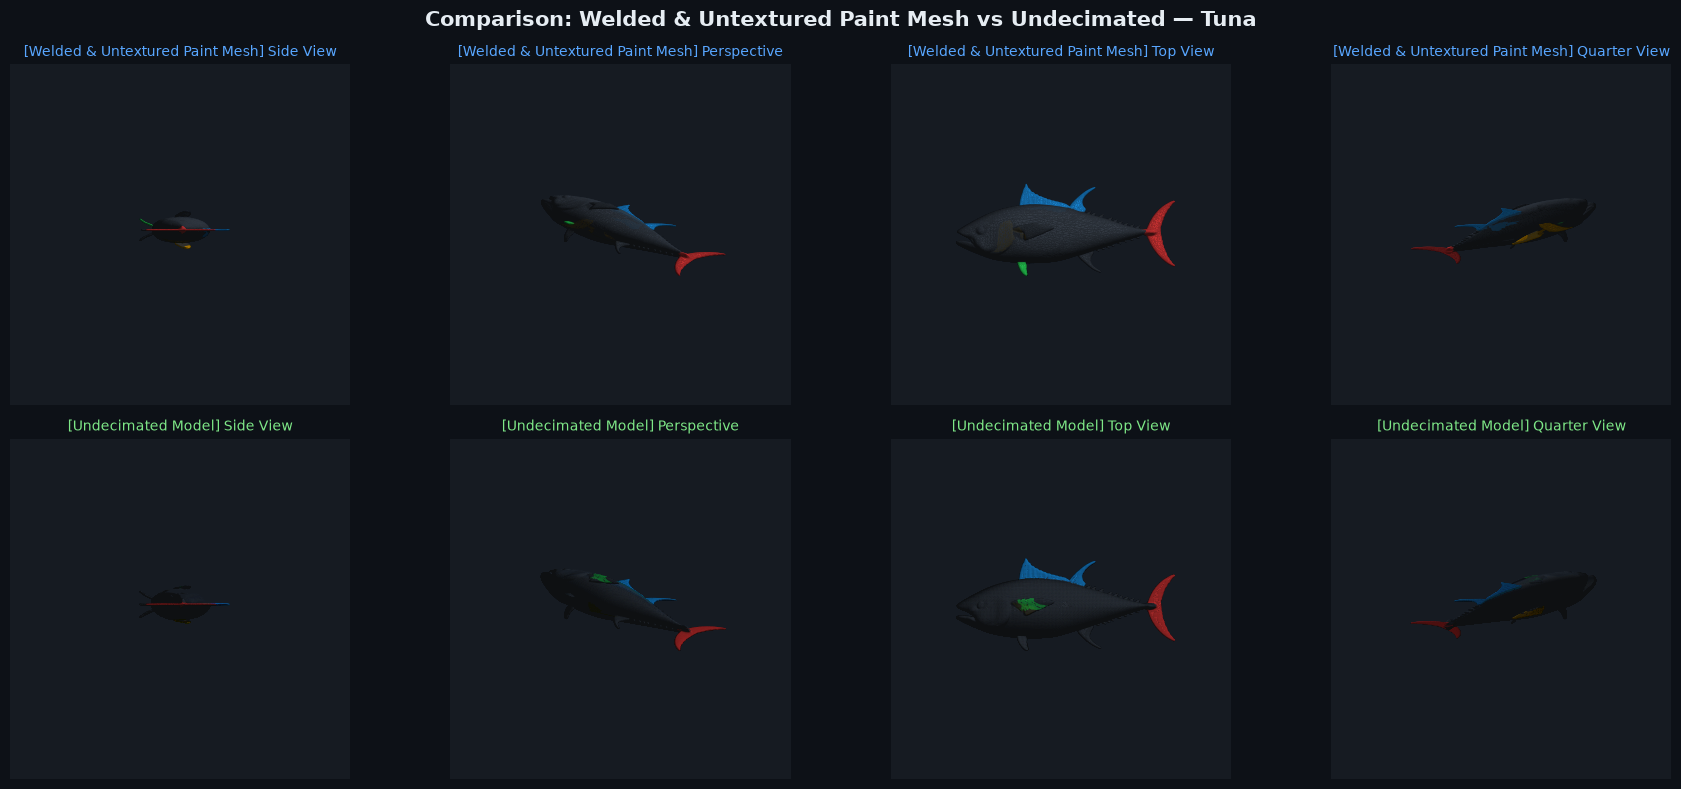


Processing Mackerel...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:00<00:00, 20.41it/s]


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:02<00:00,  7.63it/s]


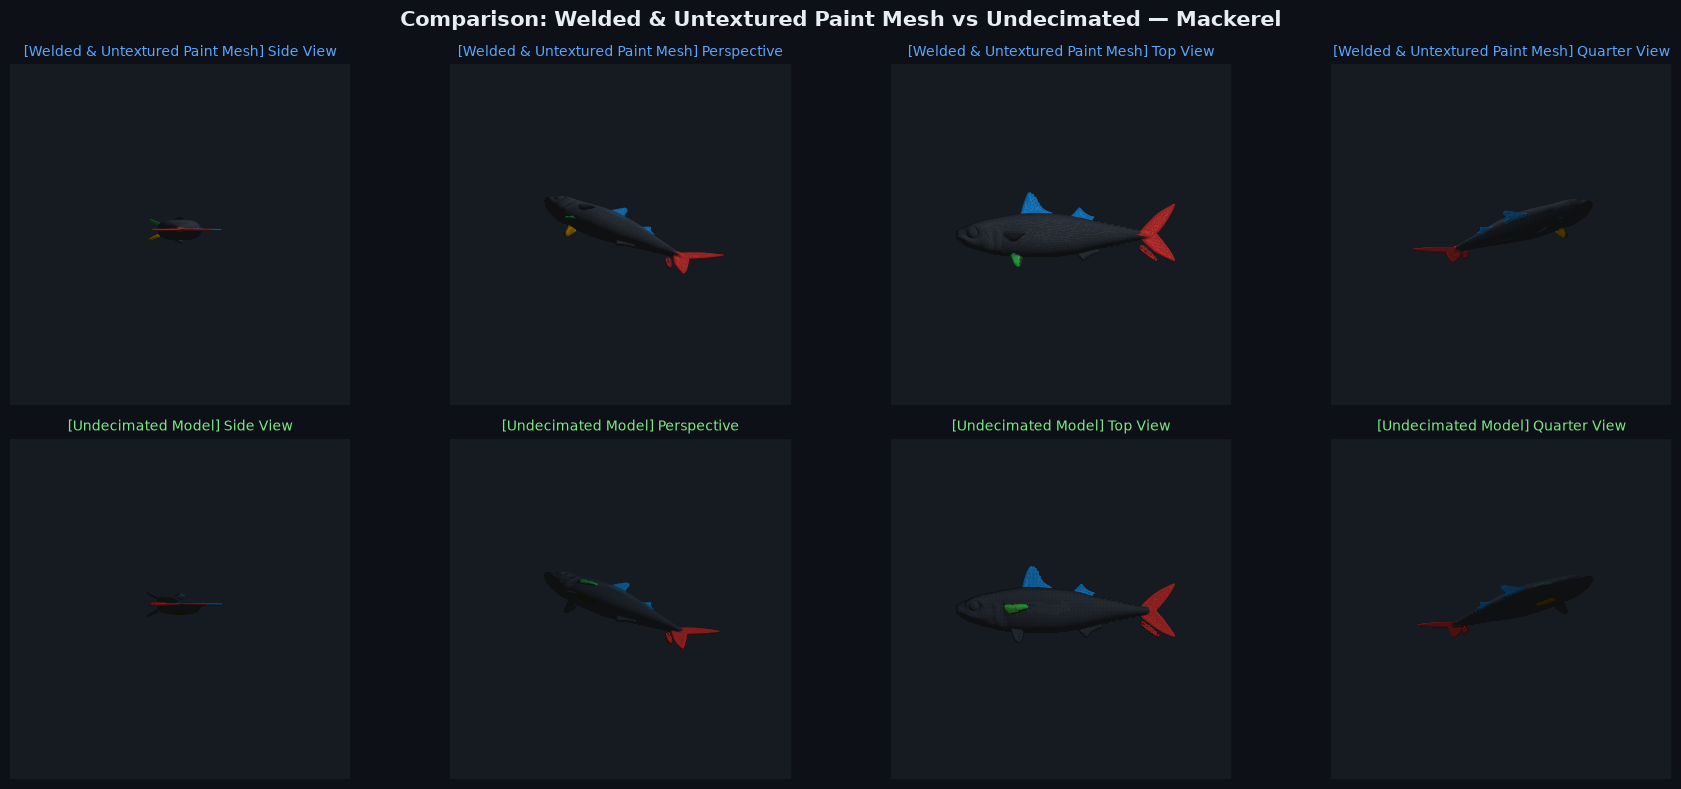


Processing Shark...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 19.36it/s]


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:02<00:00,  7.93it/s]


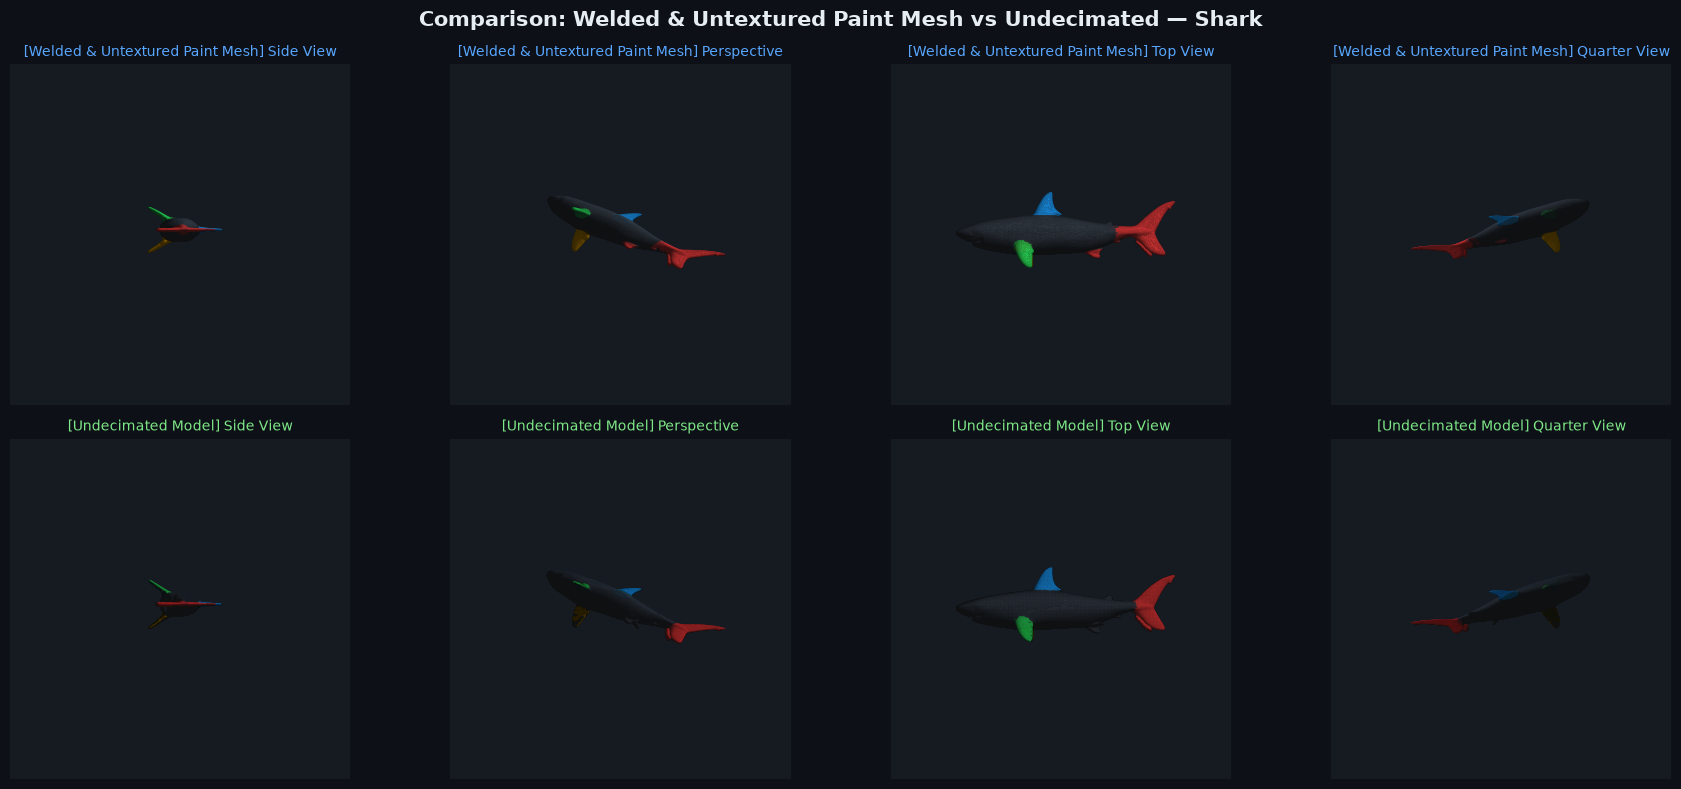


Processing Killer Whale...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 17.61it/s]


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:03<00:00,  5.94it/s]


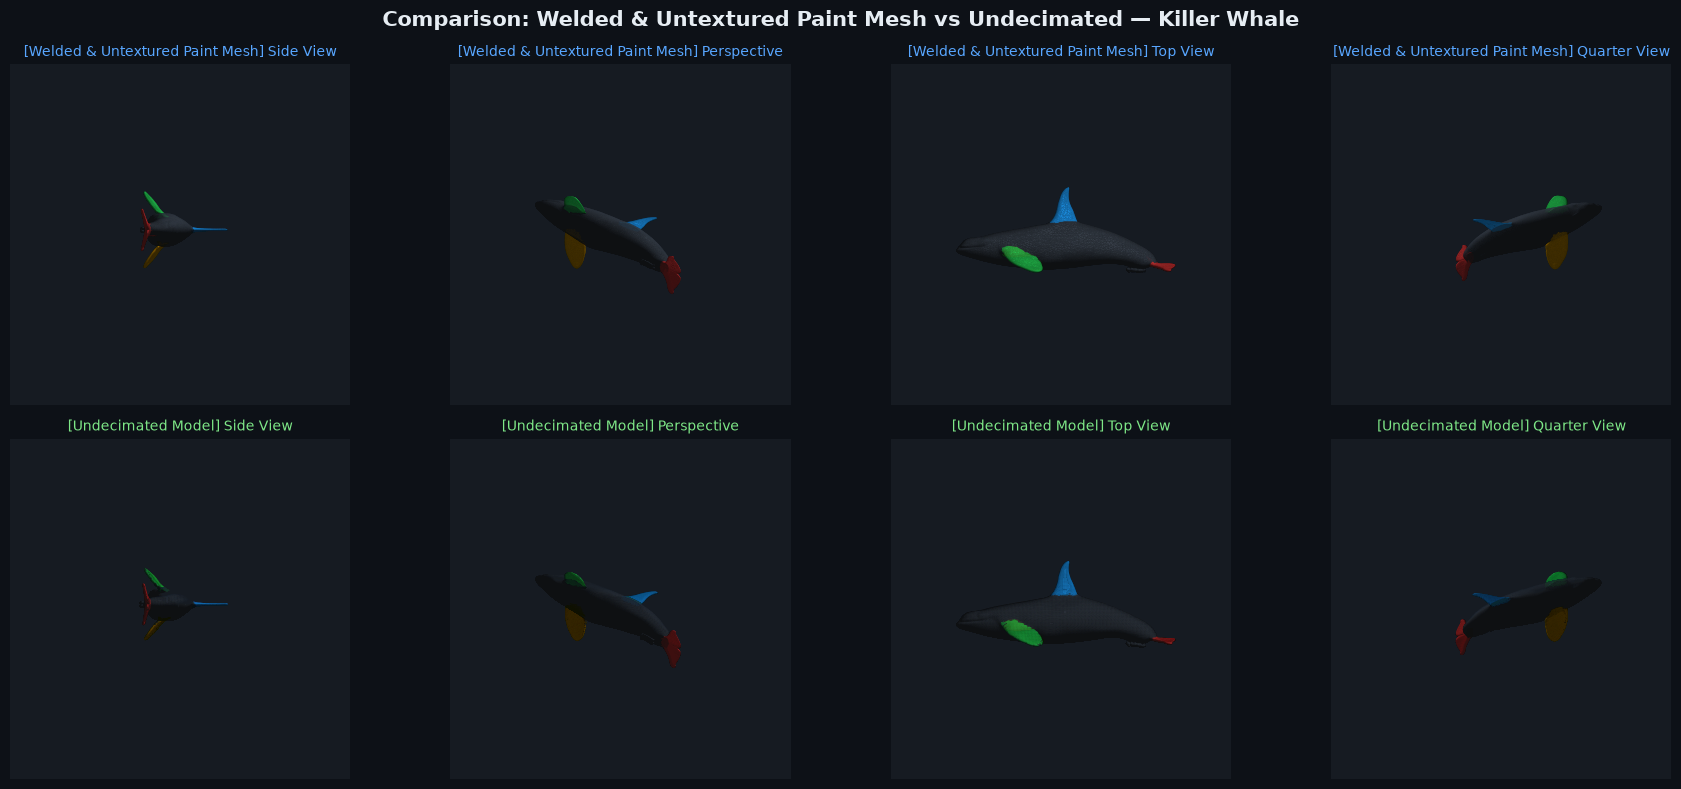


Processing Goldfish...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 16.42it/s]


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 14.05it/s]


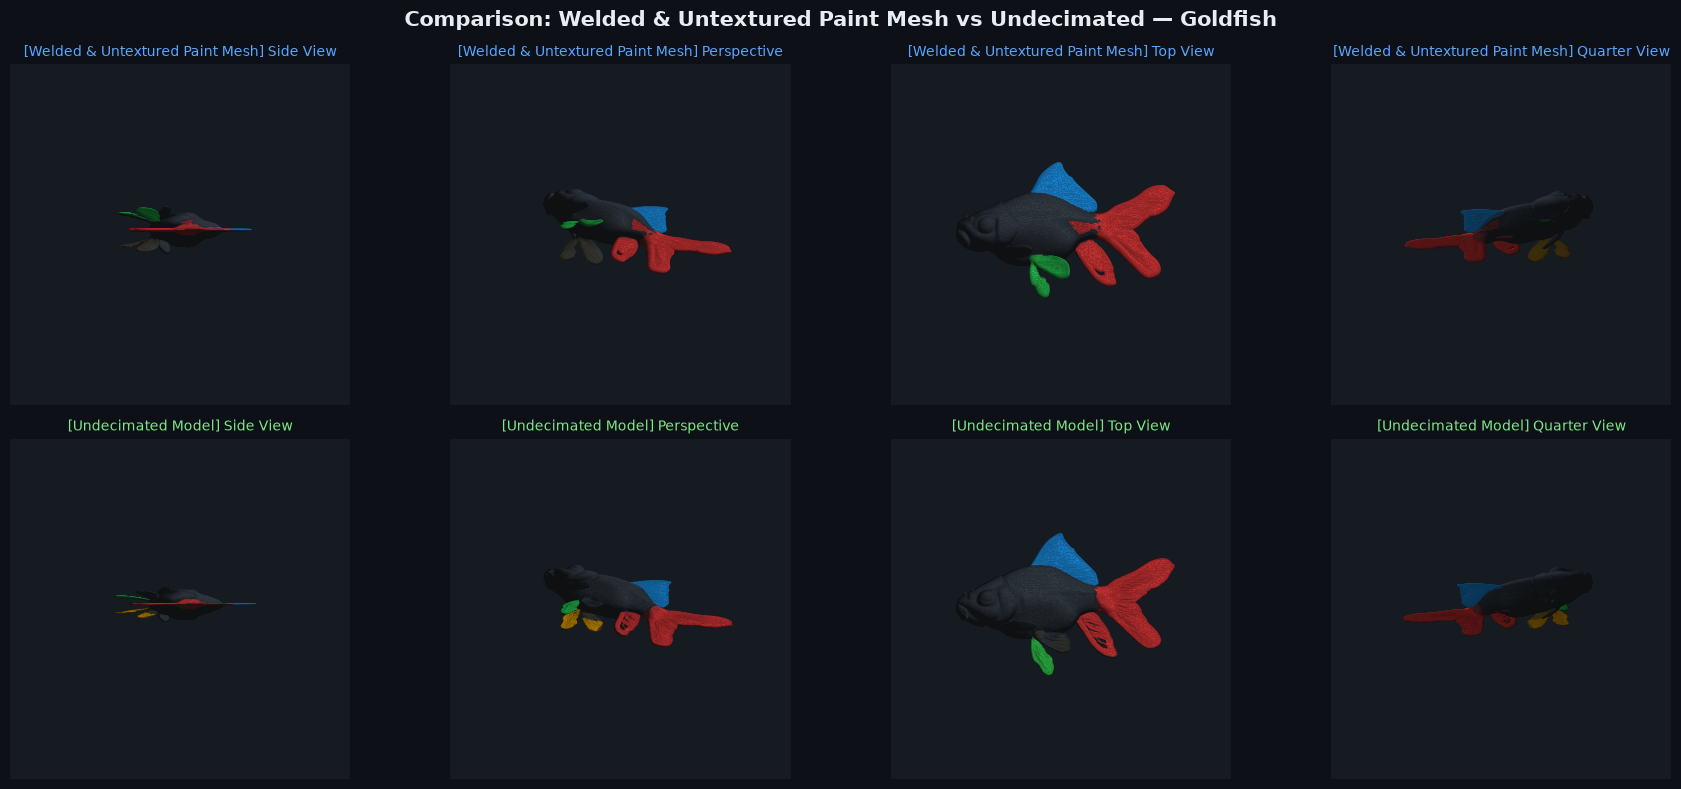


Processing Dolphin...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 18.51it/s]


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:02<00:00,  7.40it/s]


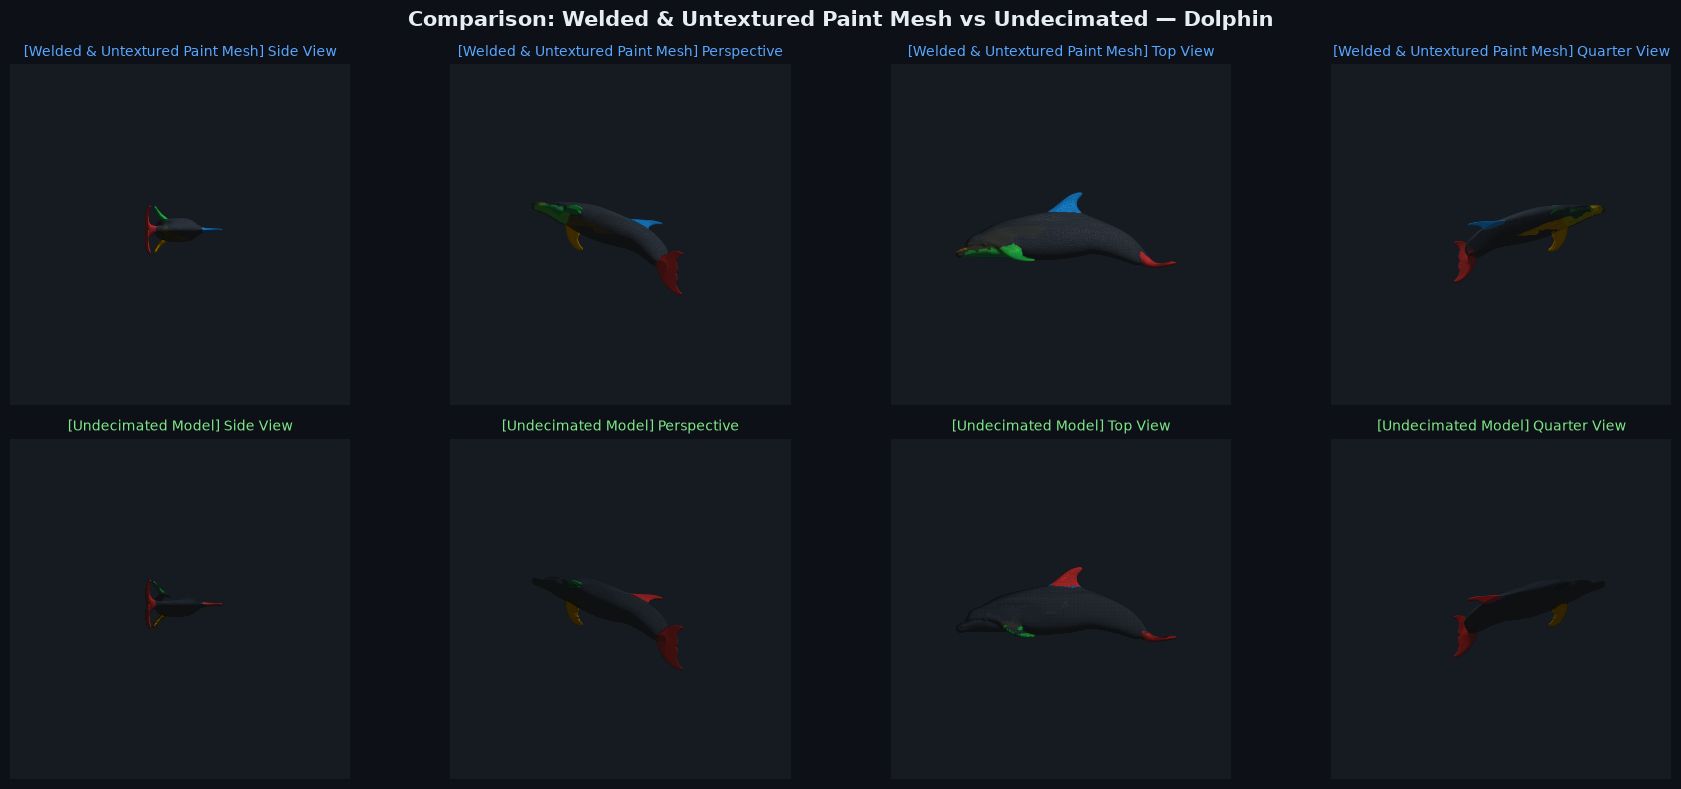

In [5]:
results = {}
for key, info in ORGANISMS.items():
    print(f"\nProcessing {info['name']}...")
    p_raw = trimesh.load(info["paint_path"], force="mesh")
    u_raw = trimesh.load(info["undec_path"], force="mesh")
    
    # Run Welded & Untextured Paint Mesh
    mesh_p, labels_p, colors_p, summary_p = segment_mesh_instance(p_raw, strip_textures=True, weld_vertices=True)
    # Run Undecimated Mesh
    mesh_u, labels_u, colors_u, summary_u = segment_mesh_instance(u_raw, strip_textures=True, weld_vertices=True)
    
    results[key] = {
        "name": info["name"],
        "paint_welded": summary_p,
        "undec": summary_u,
    }
    
    # Render Side-by-Side Figure
    fig = plt.figure(figsize=(18, 8))
    fig.patch.set_facecolor("#0D1117")
    fig.suptitle(f"Comparison: Welded & Untextured Paint Mesh vs Undecimated — {info['name']}", fontsize=15, color="#E6EDF3", fontweight="bold")
    views = [("Side View", 0, 0), ("Perspective", 25, -45), ("Top View", 90, -90), ("Quarter View", -20, 135)]
    light_dir = np.array([0.4, 0.6, 0.9]) / np.linalg.norm([0.4, 0.6, 0.9])
    
    diff_p = np.clip(np.dot(mesh_p.face_normals, light_dir), 0.25, 1.0)
    diff_u = np.clip(np.dot(mesh_u.face_normals, light_dir), 0.25, 1.0)
    
    for idx, (vname, elev, azim) in enumerate(views, 1):
        ax = fig.add_subplot(2, 4, idx, projection="3d")
        ax.set_facecolor("#161B22")
        coll = Poly3DCollection(mesh_p.vertices[mesh_p.faces], facecolors=colors_p * diff_p[:, None], edgecolors="none")
        ax.add_collection3d(coll)
        max_r = (mesh_p.vertices.max(0) - mesh_p.vertices.min(0)).max() / 2.0
        mid = (mesh_p.vertices.max(0) + mesh_p.vertices.min(0)) * 0.5
        ax.set_xlim(mid[0]-max_r, mid[0]+max_r); ax.set_ylim(mid[1]-max_r, mid[1]+max_r); ax.set_zlim(mid[2]-max_r, mid[2]+max_r)
        ax.view_init(elev=elev, azim=azim); ax.axis("off")
        ax.set_title(f"[Welded & Untextured Paint Mesh] {vname}", color="#58A6FF", fontsize=10)
        
    for idx, (vname, elev, azim) in enumerate(views, 5):
        ax = fig.add_subplot(2, 4, idx, projection="3d")
        ax.set_facecolor("#161B22")
        coll = Poly3DCollection(mesh_u.vertices[mesh_u.faces], facecolors=colors_u * diff_u[:, None], edgecolors="none")
        ax.add_collection3d(coll)
        max_r = (mesh_u.vertices.max(0) - mesh_u.vertices.min(0)).max() / 2.0
        mid = (mesh_u.vertices.max(0) + mesh_u.vertices.min(0)) * 0.5
        ax.set_xlim(mid[0]-max_r, mid[0]+max_r); ax.set_ylim(mid[1]-max_r, mid[1]+max_r); ax.set_zlim(mid[2]-max_r, mid[2]+max_r)
        ax.view_init(elev=elev, azim=azim); ax.axis("off")
        ax.set_title(f"[Undecimated Model] {vname}", color="#7EE787", fontsize=10)
        
    plt.tight_layout()
    plt.show()

## 5. Quantitative Metric Comparison Table

In [6]:
table_rows = []
for key, data in results.items():
    name = data["name"]
    for part in ["Tail Fin", "Top Fin", "Left Pectoral Fin", "Right Pectoral Fin", "Main Body"]:
        p_part = data["paint_welded"].get(part, {"faces": 0, "area_pct": 0.0, "watertight": False})
        u_part = data["undec"].get(part, {"faces": 0, "area_pct": 0.0, "watertight": False})
        table_rows.append({
            "Organism": name,
            "Part": part,
            "Paint (Welded & Clean) Faces": p_part["faces"],
            "Paint Area %": f"{p_part['area_pct']} %",
            "Paint Watertight": "✓" if p_part["watertight"] else "✗",
            "Undec Faces": u_part["faces"],
            "Undec Area %": f"{u_part['area_pct']} %",
            "Undec Watertight": "✓" if u_part["watertight"] else "✗",
        })

df_comparison = pd.DataFrame(table_rows)
display(df_comparison)

,Organism,Part,Paint (Welded & Clean) Faces,Paint Area %,Paint Watertight,Undec Faces,Undec Area %,Undec Watertight
0,Tuna,Tail Fin,2034,6.24 %,✗,10610,5.29 %,✗
1,Tuna,Top Fin,2212,6.28 %,✗,10294,4.76 %,✗
2,Tuna,Left Pectoral Fin,585,1.0 %,✗,1650,0.75 %,✗
3,Tuna,Right Pectoral Fin,1206,3.83 %,✗,3554,1.59 %,✗
4,Tuna,Main Body,15460,82.66 %,✗,207357,87.61 %,✗
5,Mackerel,Tail Fin,2960,10.99 %,✗,14806,10.03 %,✗
6,Mackerel,Top Fin,1366,5.4 %,✓,7386,4.83 %,✗
7,Mackerel,Left Pectoral Fin,490,1.21 %,✗,1276,0.73 %,✗
8,Mackerel,Right Pectoral Fin,459,1.08 %,✗,1974,1.13 %,✗
9,Mackerel,Main Body,11328,81.32 %,✗,137857,83.28 %,✗
